## Problem Definition & Data Understanding

### 🔹Business Problem

E-news Express aims to improve online subscription by redesinging its landing page. The objective of this analysis is to evaluate whether the new landing page improves user engagement (time spent on page) and conversion rate compared to the existing page.

The analysis is conducted at a 5% significance level using hypothesis testing methods.

### 🔹Questions to Answer

1. Do users spend more time on new page?
2. Is conversion rate higher?
3. Does conversion depend on language?
4. Does time spent differ across languages?

### 🔹Data Description

|column_name|description|
|--|--|
|user_id | Unique visitor|
|group| control vs treatment|
|landing_page| new vs old|
|time_spent_on_the_page| Time (in minutes)|
|converted| become subscriber (yes/no)
|language_preferred | language|

### 🔹 Inital Checks

In [1]:
#Importing common libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
original_data = pd.read_csv('dataset/abtest.csv')

In [3]:
df = original_data.copy()

In [4]:
# Displaying the first 5 rows of the dataset
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [5]:
df.shape

(100, 6)

There are `100 rows` and `6 columns` in the dataset.

So the dataset contains `100 observations` having `6 variables`.

In [6]:
# Displaying the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


The dataset consists of one numerical variable (time_spent_on_the_page) and multiple categorical variables.

In [7]:
# Displaying the statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


In [8]:
# Checking for missing values in the dataset
df.isna().sum()

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

There are no missing records.

In [9]:
# Checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

There are no duplicate records.

In [10]:
df['group'].value_counts()

group
control      50
treatment    50
Name: count, dtype: int64

> The balanced structure between control and treatment groups supports valid A/B testing assumptions.

## Exploratory Data Analysis (EDA)

### 🔹Univariate Analysis

#### Categorical :

<Axes: xlabel='landing_page', ylabel='count'>

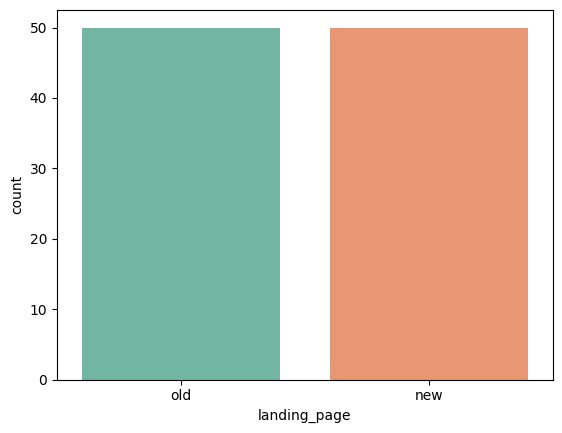

In [11]:
# Visualizing the distribution of the landing_page variable
sns.countplot(data=df, 
              x='landing_page', 
              order=df['landing_page'].value_counts().index.tolist(), 
              palette='Set2')

**Landing Page Distribution**

The bar chart above visualizes the distribution of users across the two landing page variants (old vs. new). Both variants have an equal count of **50 users**, indicating a perfectly balanced A/B test design. This equal distribution suggests that the difference in the user engagement or conversions is due to the landing page design itself and not due to the imbalance in the number of observations. This is critical measure for the hypothesis testing results.

<Axes: xlabel='group', ylabel='count'>

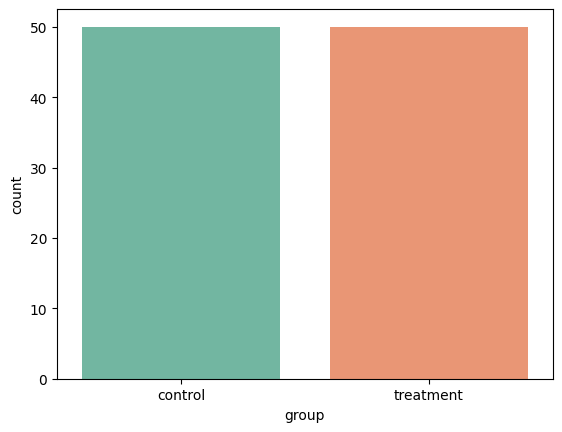

In [12]:
# Visualizing the distribution of the group variable
sns.countplot(data=df, 
              x='group',
              palette='Set2')

**Control vs Treatment Group Distribution**

The bar chart above shows the distribution of users across the control and treatment groups. Both groups contain **50 users**, demonstrating a balanced experimental design. The control group was provided with the old landing page while treatment group has been provided a experience with the new landing page. The equal distribution ensures that any difference observed between the groups is due to the landing page difference, which maintains the integrety of the A/B test.

<Axes: xlabel='landing_page', ylabel='count'>

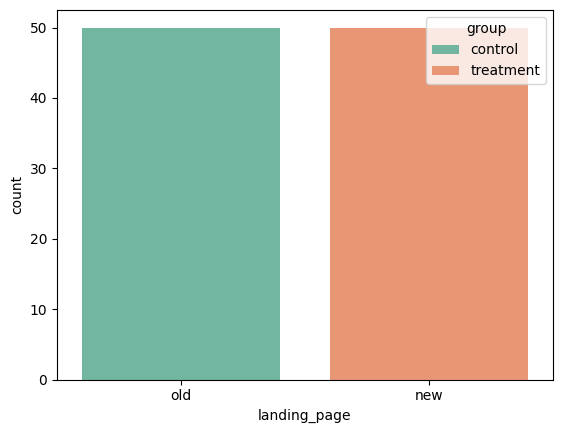

In [13]:
#visualizing the distribution of the landing page variable
sns.countplot(data=df, 
              x='landing_page',
              hue='group',
              palette='Set2')

Landing Page Distribution by Group

This visualization shows the interaction between landing page variants and experimental groups. The chart reveals:

- **Old Landing Page**: 50 users
- **New Landing Page**: 50 users 

The balanced distribution across both conditions is crucial for A/B testing validity. Each group has exactly 50 observations, ensuring that any differences in engagement or conversion metrics can be confidently attributed to the landing page design rather than sample size imbalances or selection bias.


<Axes: xlabel='converted', ylabel='count'>

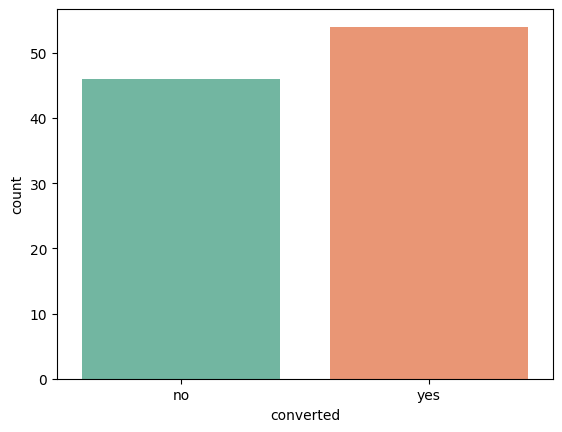

In [14]:
#visualizing the distribution of the converted variable
sns.countplot(data=df, 
              x='converted',
              palette='Set2')

**Conversion Status Distribution**

This bar chart displays the overall conversion rate in the dataset:

- **Conversion Breakdown**: The chart shows the count of users who converted (became subscribers) versus those who did not
- **Class Imbalance**: There is an imbalance in the distribution, with more converted users than non-converted users
- **Overall Rate**: This gives us a baseline understanding of the conversion rate before segmenting by landing page or other factors


<Axes: xlabel='language_preferred', ylabel='count'>

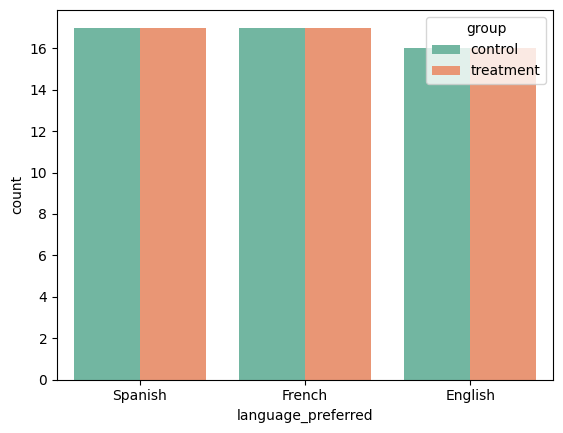

In [15]:
#visualizing the distribution of the language_preferred variable
sns.countplot(data=df, 
              x='language_preferred', 
              order=df['language_preferred'].value_counts().index.tolist(),
              palette='Set2',
              hue='group',
              hue_order=df['group'].value_counts().index.tolist())


Language distribution appears reasonably balanced across categories.

#### Numerical:

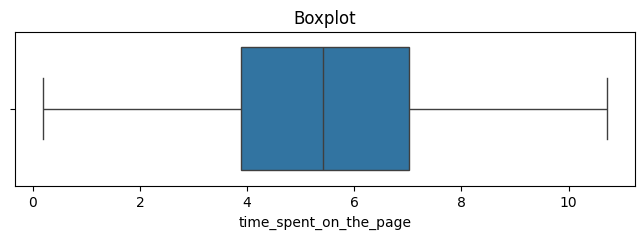

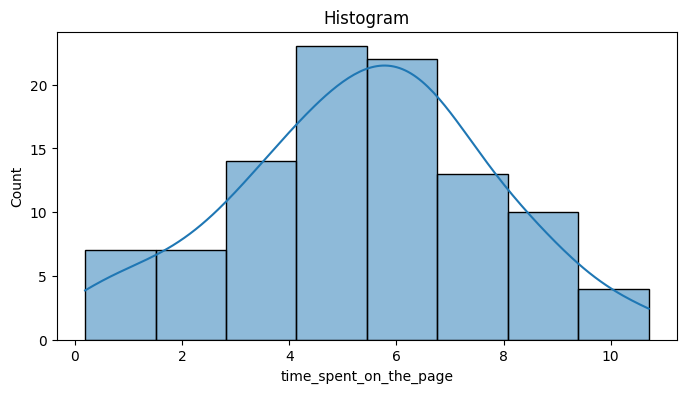

In [16]:
# Figure 1: boxplot
fig1, ax1 = plt.subplots(figsize=(8,2))
sns.boxplot(x=df['time_spent_on_the_page'], ax=ax1, color="C0")
ax1.set_title("Boxplot")

# Figure 2: histogram
fig2, ax2 = plt.subplots(figsize=(8,4))
sns.histplot(df['time_spent_on_the_page'], ax=ax2, kde=True, color="C0")
ax2.set_ylabel("Count")
ax2.set_title("Histogram")

plt.show()

The distribution of time spent on page is slightly `righ-skewed` indicating that while most users spend moderate time on the page, some user did engage significantly longer. This presence of variability suggest engagement differs across user and requires further group level comparisions.

### 🔹Bivariate Analysis

##### 🔹Landing Page Vs Time Spent

<Axes: xlabel='landing_page', ylabel='time_spent_on_the_page'>

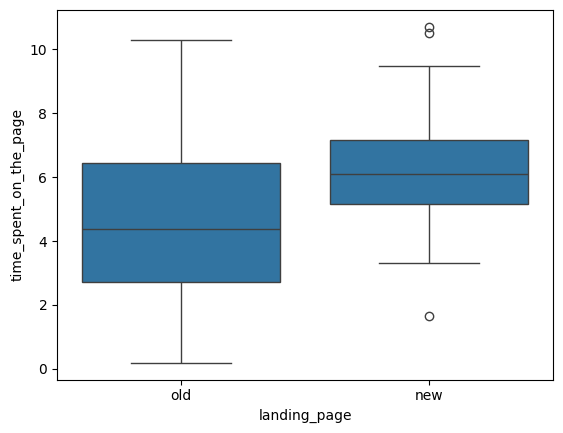

In [17]:
# Visualizing the relationship between landing_page and time_spent_on_the_page
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')

**Time Spent on Landing Page by Landing Page Variant**

This boxplot compares user engagement (time spent on page) between the old and new landing page variants:

- **Median Engagement**: The new landing page shows a higher median time spent compared to the old page
- **Distribution Spread**: Both variants show similar variability in user engagement times, though the new page appears to shift the entire distribution upward
- **Key Insight**: Users spend more time on the new page design, suggesting improved user interface (UI) usability

This visual comparison suggests that the new landing page may be more effective at retaining user attention, which can lead to higher subscription conversion rates.

##### 🔹Landing Page vs Converted

<Axes: xlabel='landing_page', ylabel='converted'>

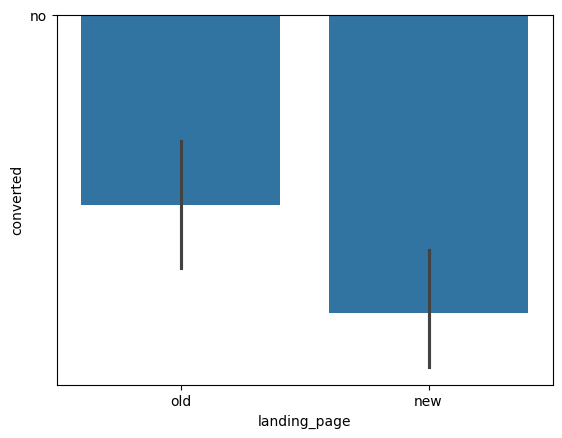

In [18]:
# Visualizing the relationship between landing_page and converted
sns.barplot(data=df, x='landing_page', y='converted')


- **New Page Performance**: The new landing page shows a visibly higher average conversion rate
- **Old Page Baseline**: The old page serves as the baseline control condition
- **Difference Magnitude**: The difference between the two charts suggests that there is an improvement in conversion with the new design

This suggests that the hypothesis that the new landing page design leads to higher user conversion rates, which will be tested statistically in the hypothesis testing section.

##### 🔹Language Vs Time spent

<Axes: xlabel='language_preferred', ylabel='time_spent_on_the_page'>

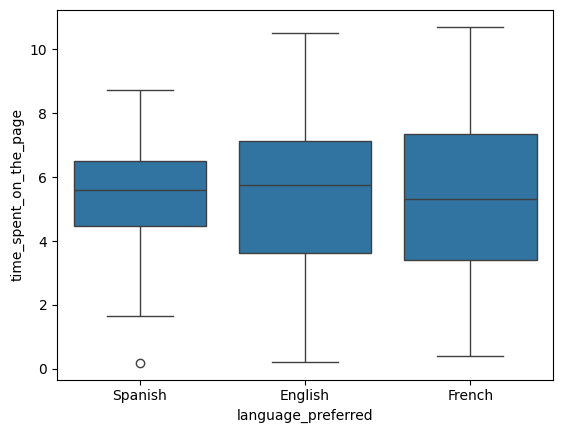

In [19]:
# Visualizing the relationship between language_preferred and time_spent_on_the_page
sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')


- **Median Consistency**: The median time spent appears relatively similar across all language groups, suggesting language preference does not significantly impact engagement time
- **Variability**: Each language group shows similar ranges and distributions of engagement times
- **Outliers**: Some outliers are present in each language category, but they don't change the overall pattern

This visual suggests that language preference alone is not a strong predictor of user engagement duration on the landing page.

##### 🔹Language Vs Converted

<Axes: xlabel='language_preferred', ylabel='count'>

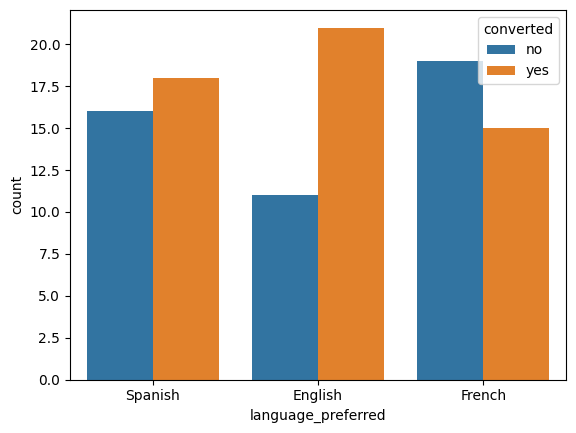

In [20]:
# Visualizing the relationship between language_preferred and converted
sns.countplot(data=df, x='language_preferred', hue='converted')


- **Conversion Patterns**: The ratio of converted to non-converted users appears consistent across different language groups
- **No Strong Association**: Each language category shows a similar proportion of yes/no conversions, indicating language preference does not substantially influence conversion likelihood
- **Balanced Representation**: All language groups have reasonable sample sizes for comparison

This visualization suggests that language preference is independent of conversion outcomes, which aligns with the later chi-square test findings.

### 🔹Hypothesis Testing

#### **Q1: Do users spend more time on the new landing page?**

##### Visual Depiction from EDA


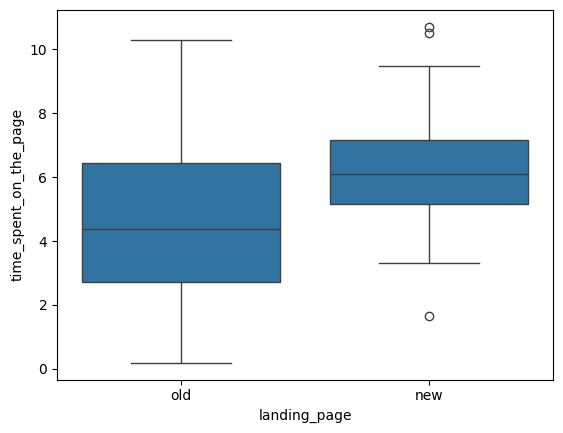

**Interpretation**
Visual inspection of the boxplot indicates that users interacting with the new landing page appear to spend slightly more time compared to those interacting with the old landing page. However, visual differences alone cannot confirm statistical significance, therefore hypothesis testing is required.

##### Hypothesis

**Null Hypothesis(H0):** The mean time spent on the new landing page is less than or equal to the mean time spent on the old landing page.

> H0 : $\mu$\_new $\le$ $\mu$\_old

**Alternative Hypothesis(H1):** The mean time spent on the new landing page is greater than the mean time spent on the old landing page.

> H1 : $\mu$\_new $\gt$ $\mu$\_old


This is `one-tailed test` because we are looking for *greater than condition*.   

##### Test Selection

> Independent Samples t-test is appropriate because
>- Comparing means of two independent group
>- Numeric dependent variable
>- Random assignment ensures independence
>

##### Data Preparation

In [21]:
old = df[df['landing_page']=='old']['time_spent_on_the_page']
new = df[df['landing_page']=='new']['time_spent_on_the_page']

The dataset is split into two groups based on the landing page to compare the mean time engagement between them.

In [49]:
#Data Preparation

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(new, old, alternative='greater', equal_var=False)

In [51]:
#Levene test
from scipy.stats import levene

l_stats, l_p_value = levene(new, old)


##### Inference

In [52]:
print (f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 3.7867702694199856, P-value: 0.0001392381225166549


In [54]:
print(f"Levene test statistic: {l_stats}, p_value: {l_p_value}")


Levene test statistic: 7.113724153407544, p_value: 0.008950671168914445


Since Levene p-value < 0.05, the equal variance assumption does **NOT hold**.

> Levene’s test was conducted to assess the equality of variances between the two groups. The p-value obtained (0.0089) is less than the significance level of 0.05, indicating that the variances are significantly different. Therefore, the equal variance assumption does not hold and Welch’s t-test is used.

> Since the p-value (0.00013) is less than the significance level of 0.05, we reject the null hypothesis. There is statistically significant evidence to conclude that users spend more time on the new landing page compared to the old landing page.

✅ Conclusion: The new page improves subscriber acquisition.

#### **Q2: Is conversion rate higher for new page?**

##### **Visual Depiction from EDA**

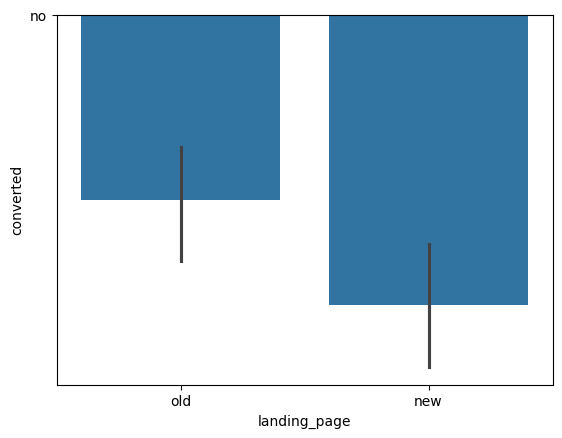

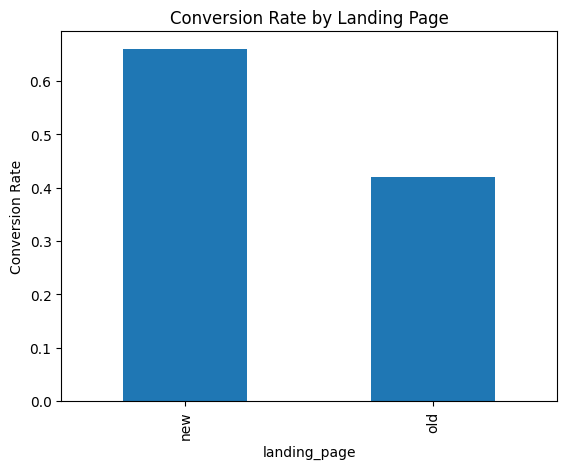

In [55]:
conversion_rate = df.groupby('landing_page')['converted'].apply(lambda x: (x == 'yes').mean())

conversion_rate.plot(kind='bar')
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Conversion Rate")
plt.show()

The bar chart suggests that the conversion rate for the new landing page appears higher than that of the old landing page. However, visual differences alone cannot confirm statistical significance, therefore a hypothesis test is required.

##### Hypothesis

**Null Hypothesis ($H_0$):** The conversion rate of the new landing page is less than or equal to the conversion rate of the old landing page.


> $H_0$ : $p_{new}$ $\le$ $p_{old}$

Alternative Hypothesis ($H_1$): The conversion rate of the new landing page is greater than the conversion rate of the old landing page.

> $H_1$ : $p_{new}$ $\gt$ $p_{old}$


This is `one-tailed` test.

A Two-Proportion Z-test is appropriate because we are comparing the proportions of a binary outcome (conversion vs no conversion) between two independent groups (old landing page and new landing page).

In [24]:
from statsmodels.stats.proportion import proportions_ztest

In [25]:
# Count conversions per landing page
conversion_counts = df.groupby('landing_page')['converted'].apply(lambda x: (x == 'yes').sum())
total_counts = df.groupby('landing_page')['converted'].count()

The number of successful conversions and total users for each landing page were extracted to compute the conversion proportions.

In [26]:
# Perform one-tailed Z-test (new > old)
z_stat, p_value = proportions_ztest(
    conversion_counts,
    total_counts,
    alternative='larger'
)


In [27]:
print("Two-Proportion Z-Test")
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Two-Proportion Z-Test
Z-statistic: 2.4077170617153842
P-value: 0.008026308204056278


Since p-value < 0.05, we reject the null hypothesis.

There is statistically significant evidence that the conversion rate for the new landing page is higher than the old page.

✅ Conclusion: The new page improves subscriber acquisition.

#### **Q3: Does conversion depend on language?**

Test: Chi-Square Test of Independence

H0: Conversion and language are independent

H1: They are associated

In [28]:
from scipy.stats import chi2_contingency

In [29]:
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])


In [30]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)


In [31]:
print("Chi-Square Test of Independence")
print("Chi-square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

Chi-Square Test of Independence
Chi-square Statistic: 3.0930306905370832
Degrees of Freedom: 2
P-value: 0.2129888748754345


Since p-value > 0.05, we fail to reject the null hypothesis.

There is no statistically significant association between language preference and conversion status.

✅ Conclusion: Conversion is independent of language.

#### Q4: Is mean time spent same across languages?

Test: One-Way ANOVA

H0: All means are equal

H1: At least one mean differs

In [32]:
from scipy.stats import f_oneway


In [33]:
languages = df['language_preferred'].unique()

In [34]:
groups = [
    df[df['language_preferred'] == lang]['time_spent_on_the_page']
    for lang in languages
]

In [35]:
f_stat, p_value = f_oneway(*groups)

In [36]:
print("One-Way ANOVA")
print("F-statistic:", f_stat)
print("P-value:", p_value)

One-Way ANOVA
F-statistic: 0.1434343922124043
P-value: 0.8665610536012648


Since p-value > 0.05, we fail to reject the null hypothesis.

There is no statistically significant difference in mean time spent across different language groups.

✅ Conclusion: Engagement time does not vary by language.

## Conclusion

This analysis evaluated the redesigned landing page using statistical hypothesis testing at a 5% significance level.

The results provide strong evidence that the new landing page significantly improves both user engagement and conversion rate. Users spend more time on the new page, and the probability of conversion is statistically higher compared to the old design.

No statistically significant relationship was found between language preference and conversion status. Similarly, time spent on the page does not vary meaningfully across language groups.

The evidence therefore isolates the landing page design itself — rather than language segmentation — as the primary driver of improved performance.

## Business Recommendations

🔹 Priority 1: Full Deployment of the New Landing Page

The most immediate and highest-impact action is to replace the old landing page with the new version. Statistical testing confirms measurable improvements in both engagement and subscriber conversion, directly impacting revenue growth.

🔹 Priority 2: Focus Optimization Efforts on Page Design, Not Language Segmentation

Since language preference does not significantly influence engagement or conversion, allocating resources toward language-specific redesign would not yield meaningful returns at this stage. Efforts should instead concentrate on refining layout, content hierarchy, and call-to-action placement.

🔹 Priority 3: Implement Continuous Experimentation Framework

While the current redesign is successful, sustained growth requires structured experimentation. Future A/B tests should target:

CTA positioning and wording

Content personalization

Visual engagement elements

Subscription incentives

A systematic experimentation roadmap will ensure ongoing performance improvement.

🔹 Priority 4: Monitor Engagement as a Leading Indicator

Time spent on the page significantly increased alongside conversion rates. Engagement should therefore be tracked as a key leading metric in future optimization strategies.

## Executive Summary

The redesigned landing page demonstrates statistically significant improvements in both user engagement and conversion performance. The primary performance driver is page design rather than language preference. Immediate deployment is recommended, supported by a structured experimentation strategy to sustain long-term growth.